# Preparation

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Global Threshold

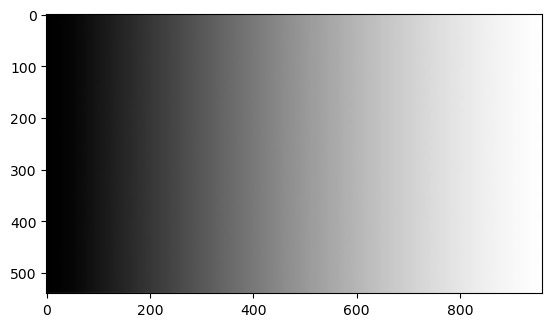

In [2]:
img = cv2.imread('../assets/gradient.jpg')

if img is None:
    raise Exception('Image is not found!')

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img)
plt.show()

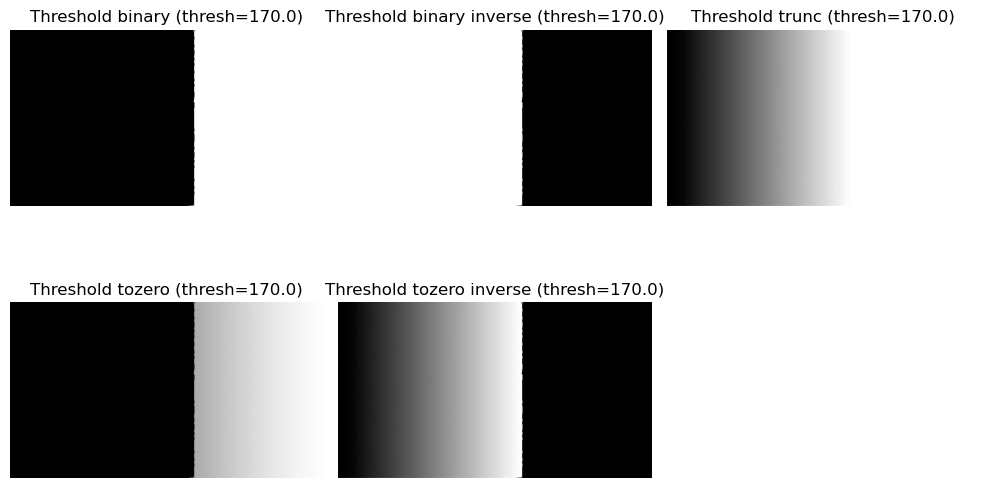

In [3]:
threshold_steps = [
    {
        'name': 'Threshold binary',
        'type': cv2.THRESH_BINARY
    },
    {
        'name': 'Threshold binary inverse',
        'type': cv2.THRESH_BINARY_INV
    },
    {
        'name': 'Threshold trunc',
        'type': cv2.THRESH_TRUNC
    },
    {
        'name': 'Threshold tozero',
        'type': cv2.THRESH_TOZERO
    },
    {
        'name': 'Threshold tozero inverse',
        'type': cv2.THRESH_TOZERO_INV
    },
]

plt.figure(figsize=(10, 6))

for i, step in enumerate(threshold_steps):
    ret, thresh_img = cv2.threshold(
        img_gray, 
        thresh=170, 
        maxval=255, 
        type=step['type']
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f'{step['name']} (thresh={ret})')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Otsu Threshold

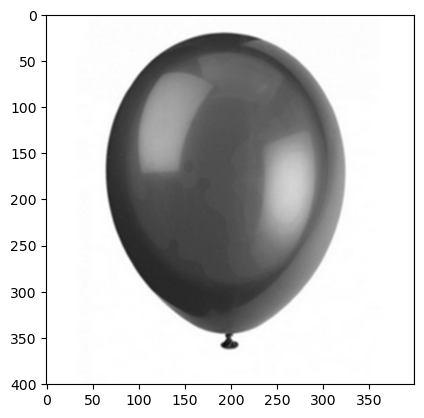

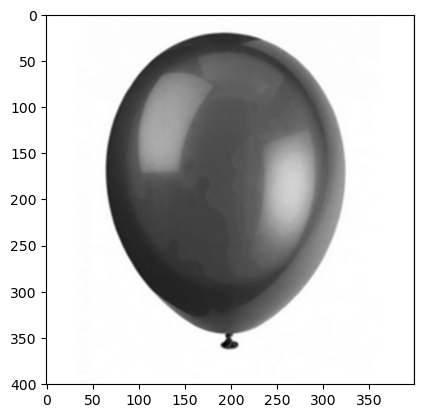

In [4]:
img_balloon = cv2.imread('../assets/balloon.png')

if img_balloon is None:
    raise Exception('Image is not found!')


img_balloon_gray = cv2.cvtColor(img_balloon, cv2.COLOR_BGR2GRAY)

plt.imshow(img_balloon)
plt.show()

plt.imshow(img_balloon_gray, cmap='gray')
plt.show()

Otsu optimal threshold: 172


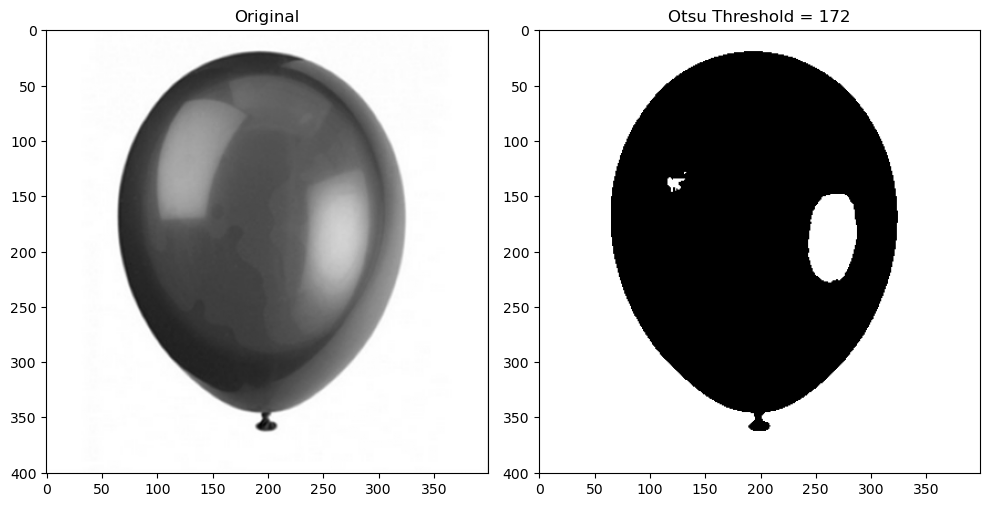

In [5]:
# iterating pixel by pixel
height, width = img_balloon_gray.shape

thresh = 170
max_val = 255


# 1. Compute histogram
hist, bins = np.histogram(img_balloon_gray.ravel(), bins=256, range=(0, 256))

# 2. Normalize histogram (to probabilities)
hist = hist.astype(np.float32)
hist /= hist.sum()

# 3. Compute cumulative sums and means
cum_sum = np.cumsum(hist)
cum_mean = np.cumsum(hist * np.arange(256))
global_mean = cum_mean[-1]

# 4. Compute between-class variance for all thresholds
var_between = (global_mean * cum_sum - cum_mean)**2 / (cum_sum * (1 - cum_sum) + 1e-10)

# 5. Find threshold that maximizes variance
otsu_thresh = np.argmax(var_between)

print("Otsu optimal threshold:", otsu_thresh)

# 6. Apply the threshold manually (Binary)
img_otsu = np.where(img_balloon_gray > otsu_thresh, 255, 0).astype(np.uint8)

# 7. Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_balloon_gray, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(img_otsu, cmap='gray')
plt.title(f'Otsu Threshold = {otsu_thresh}')

plt.tight_layout()
plt.show()

# Histogram

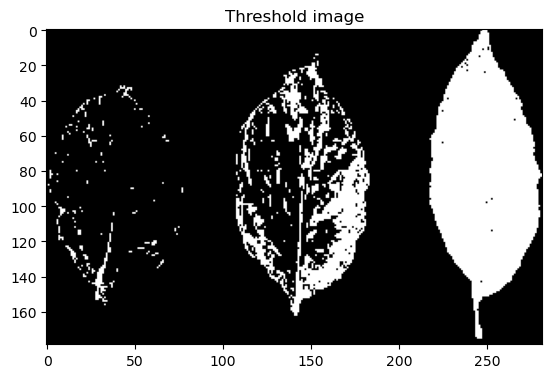

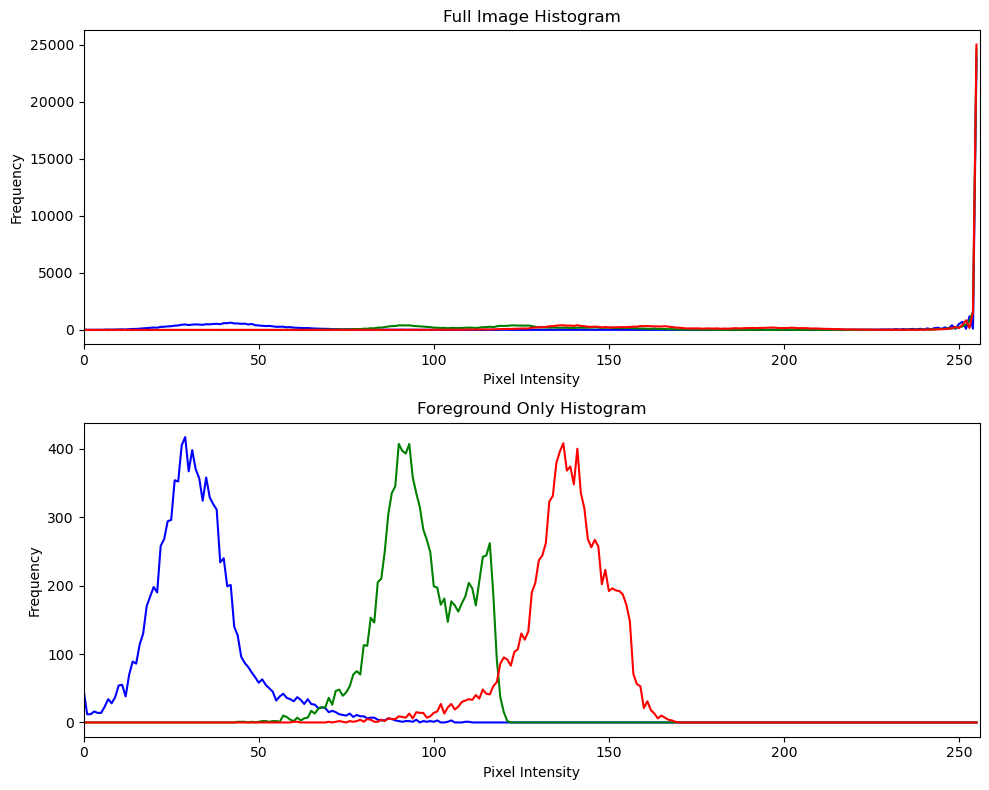

In [6]:
img_tobacco = cv2.imread('../assets/tobacco.jpeg')

if img_tobacco is None:
    raise Exception('Image is not found!')

# Convert to grayscale for mask generation
img_tobacco_gray = cv2.cvtColor(img_tobacco, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(
    img_tobacco_gray, 
    thresh=120,
    maxval=255,
    type=cv2.THRESH_BINARY_INV
)

plt.title('Threshold image')
plt.imshow(mask, cmap='gray')
plt.show()

colors = ('b', 'g', 'r')

# Create figure with 2 rows: Full Image vs Foreground
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# --------------- FULL IMAGE HISTOGRAM ----------------
for i, color in enumerate(colors):
    hist_full = cv2.calcHist(
        [img_tobacco], [i], None, [256], [0, 256]
    )
    axes[0].plot(hist_full, color=color)
axes[0].set_title('Full Image Histogram')
axes[0].set_xlim([0, 256])
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')

# --------------- FOREGROUND HISTOGRAM ----------------
for i, color in enumerate(colors):
    hist_foreground = cv2.calcHist(
        [img_tobacco], [i], mask, [256], [0, 256]
    )
    axes[1].plot(hist_foreground, color=color)
axes[1].set_title('Foreground Only Histogram')
axes[1].set_xlim([0, 256])
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Segmentation

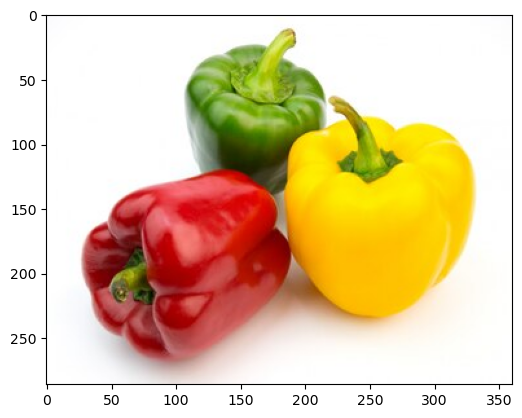

In [7]:
img_peppers = cv2.imread('../assets/peppers.jpg')

if img_peppers is None:
    raise Exception('Image is not found!')

img_peppers_rgb = cv2.cvtColor(img_peppers, cv2.COLOR_BGR2RGB)

plt.imshow(img_peppers_rgb)
plt.show()

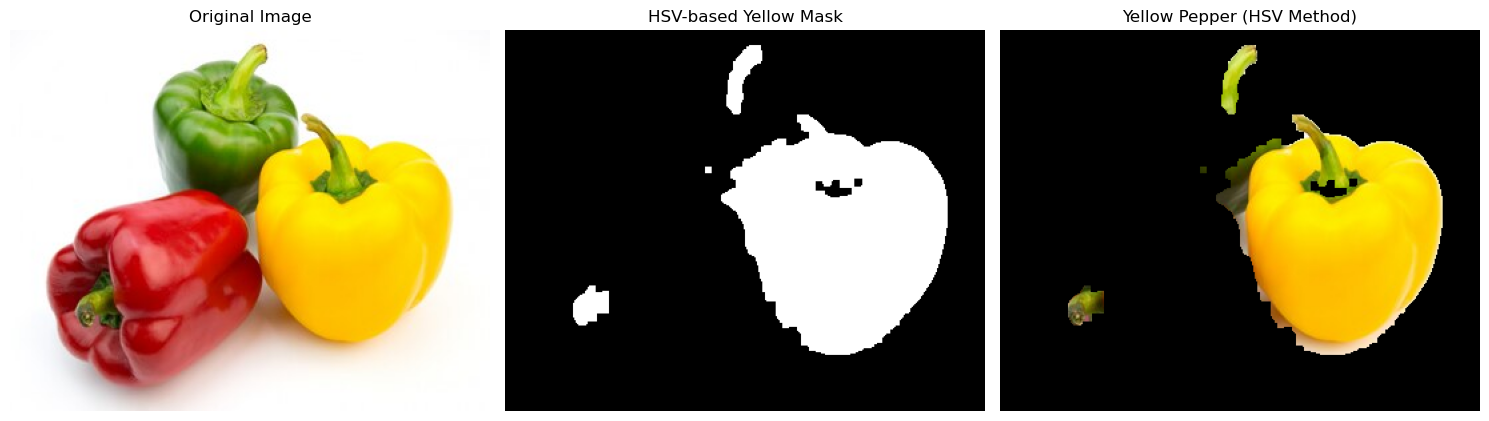

In [ ]:
# Alternative: HSV-based segmentation for yellow pepper
img_peppers_hsv = cv2.cvtColor(img_peppers, cv2.COLOR_BGR2HSV) # type: ignore

# Define yellow color range in HSV
# Yellow hue is around 20-40 degrees
lower_yellow = np.array([15, 50, 50])
upper_yellow = np.array([35, 255, 255])

# Create mask
yellow_mask_hsv = cv2.inRange(img_peppers_hsv, lower_yellow, upper_yellow)

# Apply morphological operations to clean up mask
kernel = np.ones((5, 5), np.uint8)
yellow_mask_hsv = cv2.morphologyEx(yellow_mask_hsv, cv2.MORPH_CLOSE, kernel)
yellow_mask_hsv = cv2.morphologyEx(yellow_mask_hsv, cv2.MORPH_OPEN, kernel)

# Extract yellow pepper
yellow_pepper_hsv = cv2.bitwise_and(
    img_peppers_rgb, 
    img_peppers_rgb, 
    mask=yellow_mask_hsv
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_peppers_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(yellow_mask_hsv, cmap='gray')
plt.title('HSV-based Yellow Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(yellow_pepper_hsv)
plt.title('Yellow Pepper (HSV Method)')
plt.axis('off')

plt.tight_layout()
plt.show()

I successfully managed to display only the yellow pepper. Previously, I tried to process the image directly from the original image loaded by OpenCV, which uses the BGR format. It wasn’t easy to select the correct color, and sometimes it affected other objects with different colors.

Then, I tried another method by processing the image in HSV format. Based on my experiment, it’s much easier to mask the yellow pepper this way. The HSV format is closer to how humans perceive color, so it makes image processing much easier compared to BGR. Another reason is that masking in BGR format—especially for object masking—is sometimes harder. For example, what looks like green to human eyes is actually a combination of red, green, and blue values in each pixel.

# Case Study Threshold

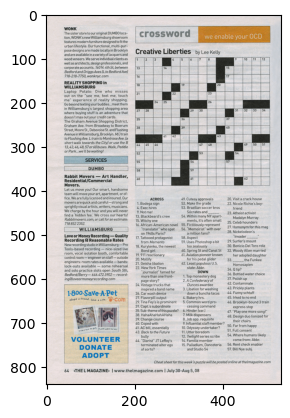

In [10]:
img_crossword = cv2.imread('../assets/crossword.jpg')

if img_crossword is None:
    raise Exception('Image is not found!')

img_crossword_rgb = cv2.cvtColor(img_crossword, cv2.COLOR_BGR2RGB)

plt.imshow(img_crossword_rgb)
plt.show()

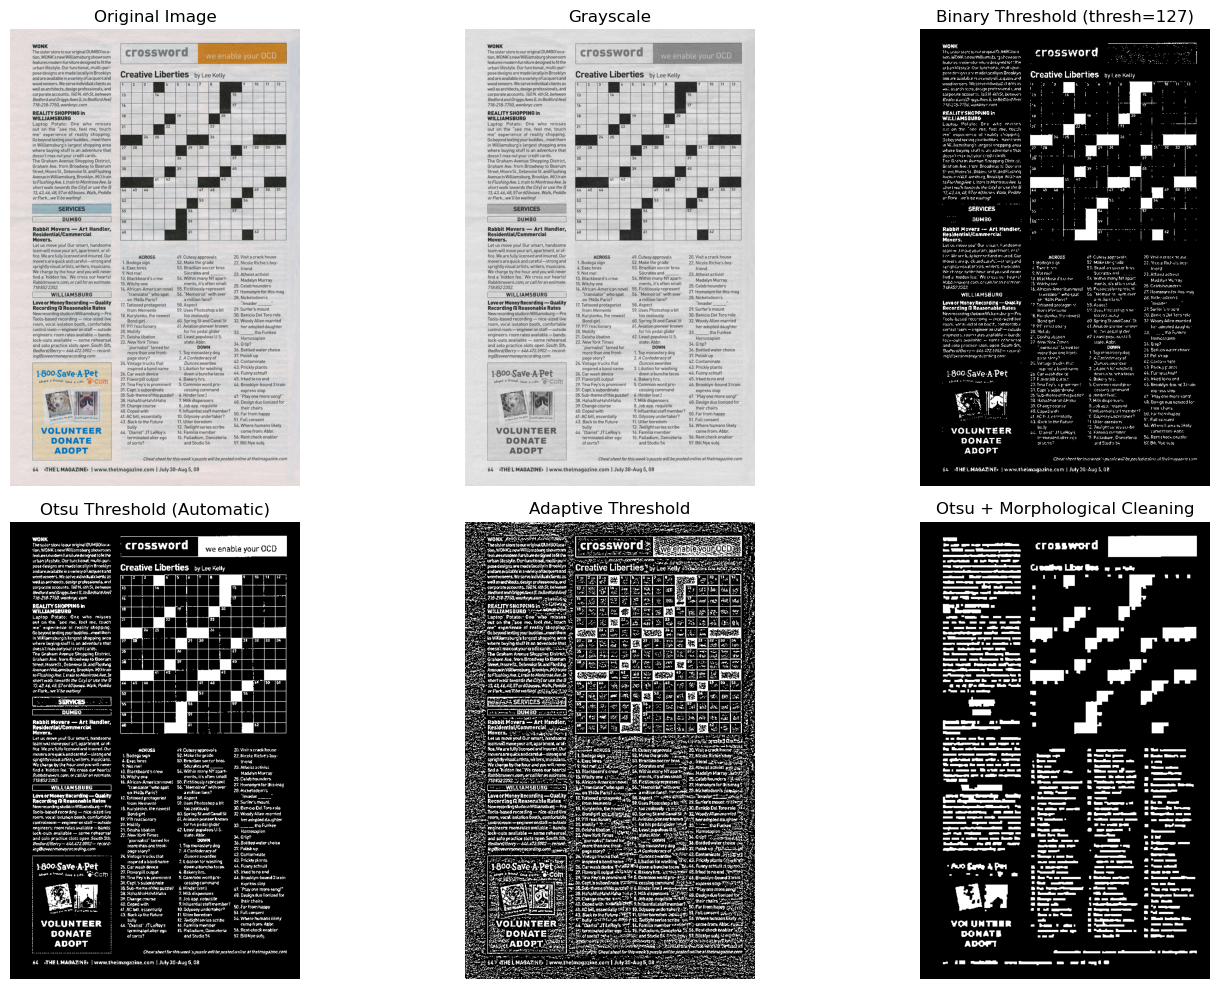

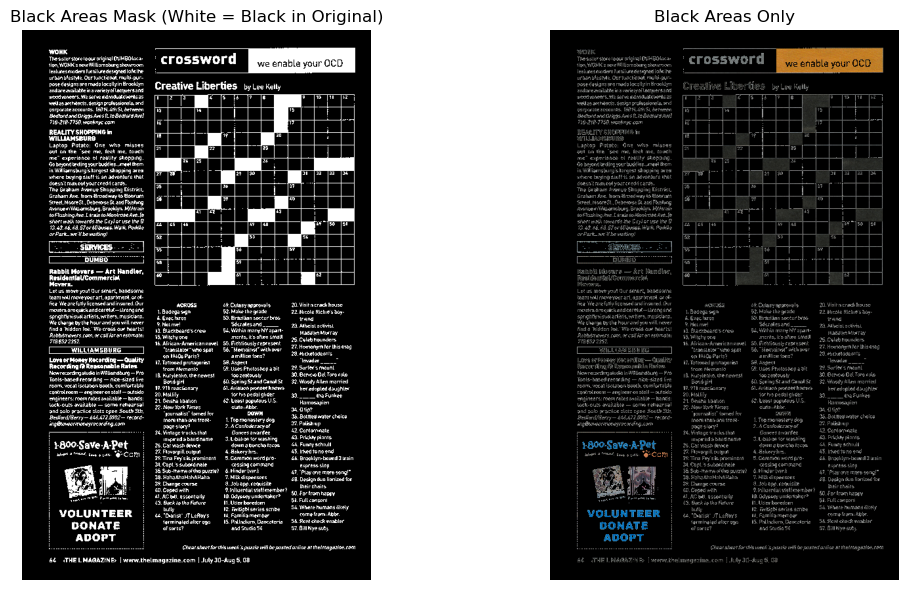

In [ ]:
# Convert to grayscale
img_crossword_gray = cv2.cvtColor(img_crossword, cv2.COLOR_BGR2GRAY) # type: ignore

# Method 1: Simple Binary Threshold
_, thresh_binary = cv2.threshold(
    img_crossword_gray, 
    thresh=127, 
    maxval=255, 
    type=cv2.THRESH_BINARY_INV
)

# Method 2: Otsu's Automatic Threshold
_, thresh_otsu = cv2.threshold(
    img_crossword_gray, 
    0, 
    255, 
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Method 3: Adaptive Threshold (works well with varying lighting)
thresh_adaptive = cv2.adaptiveThreshold(
    img_crossword_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    blockSize=11,
    C=2
)

# Method 4: Apply morphological operations to clean up
kernel = np.ones((3, 3), np.uint8)
thresh_morph = cv2.morphologyEx(thresh_otsu, cv2.MORPH_CLOSE, kernel)
thresh_morph = cv2.morphologyEx(thresh_morph, cv2.MORPH_OPEN, kernel)

# Display all methods
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_crossword_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_crossword_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(thresh_binary, cmap='gray')
plt.title('Binary Threshold (thresh=127)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(thresh_otsu, cmap='gray')
plt.title('Otsu Threshold (Automatic)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(thresh_adaptive, cmap='gray')
plt.title('Adaptive Threshold')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(thresh_morph, cmap='gray')
plt.title('Otsu + Morphological Cleaning')
plt.axis('off')

plt.tight_layout()
plt.show()

# Show only the black areas on original image
crossword_black_only = cv2.bitwise_and(
    img_crossword_rgb, 
    img_crossword_rgb, 
    mask=thresh_otsu
)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(thresh_otsu, cmap='gray')
plt.title('Black Areas Mask (White = Black in Original)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(crossword_black_only)
plt.title('Black Areas Only')
plt.axis('off')

plt.tight_layout()
plt.show()